## Comparación de CNNs para detección de dígitos SVHN

Este notebook reemplaza la arquitectura LeNet-5 de MNIST por una comparación de dos CNNs distintas sobre el dataset SVHN.

Se entrenan dos modelos con diferencias en optimizador, learning rate, batch size y regularización para comparar su rendimiento.


In [ ]:
# importa las librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
import numpy as np
import scipy.io
import tensorflow as tf


In [ ]:



def load_svhn():
    # Descarga directa con caché local (se descarga una sola vez)
    train_path = tf.keras.utils.get_file(
        'train_32x32.mat',
        'http://ufldl.stanford.edu/housenumbers/train_32x32.mat'
    )
    test_path = tf.keras.utils.get_file(
        'test_32x32.mat',
        'http://ufldl.stanford.edu/housenumbers/test_32x32.mat'
    )

    # Cargar archivos .mat
    train_raw = scipy.io.loadmat(train_path)
    test_raw = scipy.io.loadmat(test_path)

    # Transponer a formato (N, H, W, C)
    x_train = np.transpose(train_raw['X'], (3, 0, 1, 2))
    y_train = train_raw['y'].flatten()

    x_test = np.transpose(test_raw['X'], (3, 0, 1, 2))
    y_test = test_raw['y'].flatten()

    # Ajustar etiqueta de MATLAB (el dígito 0 viene como 10)
    y_train[y_train == 10] = 0
    y_test[y_test == 10] = 0

    return (x_train, y_train), (x_test, y_test)


(x_train, y_train), (x_test, y_test) = load_svhn()

# Alias para mantener coherencia con el resto del notebook
x_train = x_train.copy()
x_test_raw = x_test.copy()

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_test_raw shape:', x_test_raw.shape)
print('y_test shape:', y_test.shape)


x_train shape: (73257, 32, 32, 3)
y_train shape: (73257,)
x_test_raw shape: (26032, 32, 32, 3)
y_test shape: (26032,)


In [ ]:
# inspecciona los arrays cargados con NumPy
print('x_train dtype:', x_train.dtype)
print('y_train dtype:', y_train.dtype)
print('x_test dtype:', x_test.dtype)
print('y_test dtype:', y_test.dtype)

print('Dimensiones:')
print('x_train:', x_train.shape)
print('x_test :', x_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)


x_train dtype: uint8
y_train dtype: uint8
x_test dtype: uint8
y_test dtype: uint8
Dimensiones:
x_train: (73257, 32, 32, 3)
x_test : (26032, 32, 32, 3)
y_train: (73257,)
y_test : (26032,)


In [ ]:
# valida y separa conjunto de validación usando los arrays cargados
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.15,
    random_state=42,
    stratify=y_train
)

print('x_train shape:', x_train.shape)
print('x_val shape:', x_val.shape)
print('x_test shape:', x_test.shape)


x_train shape: (62268, 32, 32, 3)
x_val shape: (10989, 32, 32, 3)
x_test shape: (26032, 32, 32, 3)


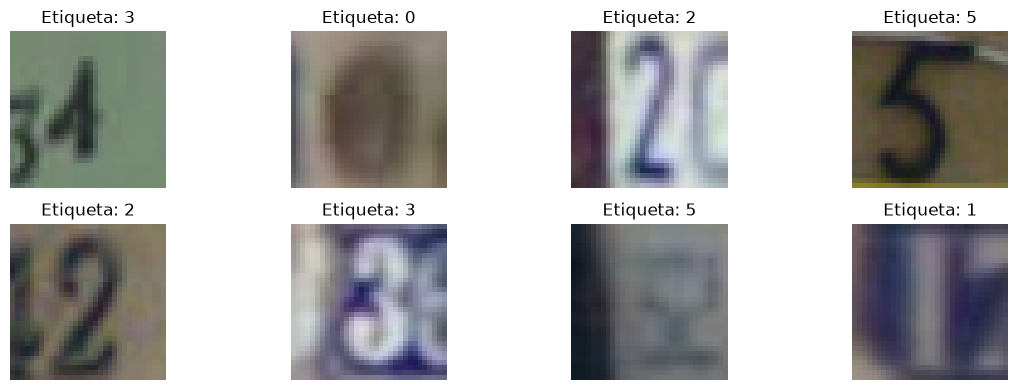

In [ ]:
# normaliza las imágenes y muestra ejemplos
x_train = x_train.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0
x_test = x_test_raw.astype('float32') / 255.0

labels_dict = {0:'0',1:'1',2:'2',3:'3',4:'4',5:'5',6:'6',7:'7',8:'8',9:'9'}
indices = [0, 12, 35, 60, 101, 220, 310, 450]

plt.figure(figsize=(12, 4))
for i, idx in enumerate(indices, 1):
    plt.subplot(2, 4, i)
    plt.imshow(x_train[idx])
    plt.title(f"Etiqueta: {labels_dict[y_train[idx]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# one-hot encoding
num_classes = 10
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
y_val_cat = tf.keras.utils.to_categorical(y_val, num_classes)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes)

print(y_train[0], '->', y_train_cat[0])


3 -> [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


In [ ]:
# define la primera arquitectura CNN

def build_cnn_model_1():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.25),

        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.30),

        tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.GlobalAveragePooling2D(),

        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.40),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

cnn1 = build_cnn_model_1()
cnn1.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,122 (617.66 KB)

 Trainable params: 157,674 (615.91 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:


def build_cnn_model_2():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),
        tf.keras.layers.Conv2D(16, (3, 3), activation='gelu', padding='same'),
        tf.keras.layers.Conv2D(16, (3, 3), activation='gelu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.20),

        tf.keras.layers.Conv2D(32, (3, 3), activation='gelu', padding='same'),
        tf.keras.layers.Conv2D(32, (3, 3), activation='gelu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.20),

        tf.keras.layers.Conv2D(64, (3, 3), activation='gelu', padding='same'),
        tf.keras.layers.Conv2D(64, (3, 3), activation='gelu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.25),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='gelu'),
        tf.keras.layers.Dropout(0.35),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

cnn2 = build_cnn_model_2()
cnn2.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 204,570 (799.10 KB)

 Trainable params: 204,570 (799.10 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compila y entrena CNN 1
cnn1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history_1 = cnn1.fit(
    x_train, y_train_cat,
    validation_data=(x_val, y_val_cat),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop_1],
    verbose=1
)


Epoch 1/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 24s 23ms/step - accuracy: 0.6670 - loss: 1.0046 - val_accuracy: 0.8692 - val_loss: 0.4311
Epoch 2/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.8837 - loss: 0.3881 - val_accuracy: 0.9122 - val_loss: 0.2927
Epoch 3/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.9034 - loss: 0.3248 - val_accuracy: 0.9161 - val_loss: 0.2858
Epoch 4/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - accuracy: 0.9145 - loss: 0.2940 - val_accuracy: 0.9196 - val_loss: 0.2659
Epoch 5/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - accuracy: 0.9206 - loss: 0.2719 - val_accuracy: 0.9351 - val_loss: 0.2283
Epoch 6/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.9254 - loss: 0.2577 - val_accuracy: 0.9016 - val_loss: 0.3162
Epoch 7/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.9301 - loss: 0.2423 - val_accuracy: 0.9387 - val_loss: 0.2155
Epoch 8/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.9332 - loss: 0.2337 - 

In [ ]:
# compila y entrena CNN 2
cnn2.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history_2 = cnn2.fit(
    x_train, y_train_cat,
    validation_data=(x_val, y_val_cat),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop_2],
    verbose=1
)


Epoch 1/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.1946 - loss: 2.2275 - val_accuracy: 0.3040 - val_loss: 1.9939
Epoch 2/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.5824 - loss: 1.2622 - val_accuracy: 0.7770 - val_loss: 0.7124
Epoch 3/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.7677 - loss: 0.7276 - val_accuracy: 0.8425 - val_loss: 0.5071
Epoch 4/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.8212 - loss: 0.5707 - val_accuracy: 0.8664 - val_loss: 0.4275
Epoch 5/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.8504 - loss: 0.4810 - val_accuracy: 0.8865 - val_loss: 0.3697
Epoch 6/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.8711 - loss: 0.4179 - val_accuracy: 0.9017 - val_loss: 0.3307
Epoch 7/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.8858 - loss: 0.3765 - val_accuracy: 0.9060 - val_loss: 0.3181
Epoch 8/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.8954 - loss: 0.3429 - 

In [ ]:
# función para evaluar cada modelo

def evaluate_model(model, x_data, y_true_cat, y_true_labels, batch_size=128):
    pred_probs = model.predict(x_data, batch_size=batch_size, verbose=0)
    pred_labels = pred_probs.argmax(axis=1)

    acc = model.evaluate(x_data, y_true_cat, verbose=0)[1]
    report = classification_report(y_true_labels, pred_labels, digits=4)
    cm = confusion_matrix(y_true_labels, pred_labels)
    f1_macro = f1_score(y_true_labels, pred_labels, average='macro')

    return {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'report': report,
        'confusion_matrix': cm,
        'pred_labels': pred_labels
    }

res1 = evaluate_model(cnn1, x_test, y_test_cat, y_test, batch_size=128)
res2 = evaluate_model(cnn2, x_test, y_test_cat, y_test, batch_size=128)

print('=== Modelo 1 ===')
print('Accuracy:', res1['accuracy'])
print('F1 macro:', res1['f1_macro'])
print(res1['report'])
print(res1['confusion_matrix'])

print('\n=== Modelo 2 ===')
print('Accuracy:', res2['accuracy'])
print('F1 macro:', res2['f1_macro'])
print(res2['report'])
print(res2['confusion_matrix'])


=== Modelo 1 ===
Accuracy: 0.9484865069389343
F1 macro: 0.9438339191616395
              precision    recall  f1-score   support

           0     0.9417    0.9455    0.9436      1744
           1     0.9584    0.9667    0.9625      5099
           2     0.9741    0.9593    0.9666      4149
           3     0.9248    0.9257    0.9253      2882
           4     0.9738    0.9572    0.9654      2523
           5     0.9545    0.9501    0.9523      2384
           6     0.9049    0.9621    0.9326      1977
           7     0.9604    0.9371    0.9486      2019
           8     0.9373    0.9090    0.9229      1660
           9     0.9081    0.9292    0.9185      1595

    accuracy                         0.9485     26032
   macro avg     0.9438    0.9442    0.9438     26032
weighted avg     0.9488    0.9485    0.9485     26032

[[1649   17    5    7    2    4   32    3   15   10]
 [  22 4929   28   24   19   10   21   39    6    1]
 [   6   25 3980   66   17    3    9   22    8   13]
 [   6 

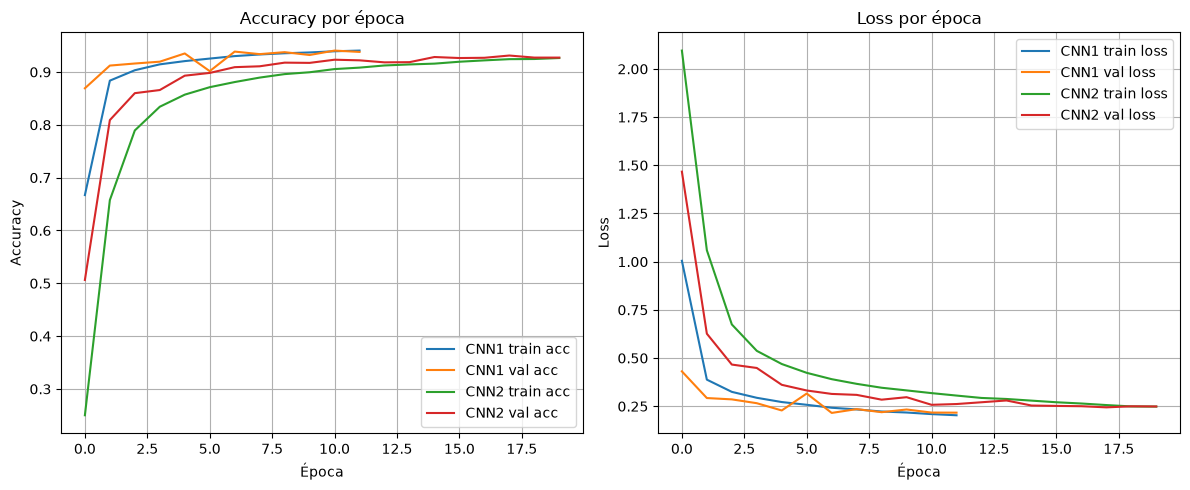

In [ ]:
# curvas de aprendizaje de ambas arquitecturas
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_1.history['accuracy'], label='CNN1 train acc')
plt.plot(history_1.history['val_accuracy'], label='CNN1 val acc')
plt.plot(history_2.history['accuracy'], label='CNN2 train acc')
plt.plot(history_2.history['val_accuracy'], label='CNN2 val acc')
plt.title('Accuracy por época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_1.history['loss'], label='CNN1 train loss')
plt.plot(history_1.history['val_loss'], label='CNN1 val loss')
plt.plot(history_2.history['loss'], label='CNN2 train loss')
plt.plot(history_2.history['val_loss'], label='CNN2 val loss')
plt.title('Loss por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# tabla comparativa final
cnn1_params = cnn1.count_params()
cnn2_params = cnn2.count_params()

comparison = pd.DataFrame([
    {
        'Modelo': 'CNN 1',
        'Optimizador': 'Adam',
        'Learning rate': 1e-3,
        'Batch size': 64,
        'Epochs': len(history_1.history['loss']),
        'Dropout': '0.25 / 0.30 / 0.40',
        'Parámetros': cnn1_params,
        'Train accuracy': round(max(history_1.history['accuracy']), 4),
        'Val accuracy': round(max(history_1.history['val_accuracy']), 4),
        'Val loss': round(min(history_1.history['val_loss']), 4),
        'F1 macro': round(res1['f1_macro'], 4)
    },
    {
        'Modelo': 'CNN 2',
        'Optimizador': 'RMSprop',
        'Learning rate': 5e-4,
        'Batch size': 128,
        'Epochs': len(history_2.history['loss']),
        'Dropout': '0.20 / 0.25 / 0.35',
        'Parámetros': cnn2_params,
        'Train accuracy': round(max(history_2.history['accuracy']), 4),
        'Val accuracy': round(max(history_2.history['val_accuracy']), 4),
        'Val loss': round(min(history_2.history['val_loss']), 4),
        'F1 macro': round(res2['f1_macro'], 4)
    }
])

comparison


,Modelo,Optimizador,Learning rate,Batch size,Epochs,Dropout,Parámetros,Train accuracy,Val accuracy,Val loss,F1 macro
0,CNN 1,Adam,0.0010,64,12,0.25 / 0.30 / 0.40,158122,0.9406,0.9406,0.2155,0.9438
1,CNN 2,RMSprop,0.0005,128,20,0.20 / 0.25 / 0.35,204570,0.9265,0.9312,0.2444,0.9298


Reflexión Final

Finalizando esta actividad, encuentro bastantes similaridades, pero también algunos matices, con respecto a las actividades realizadas a principio del periodo. Primero que todo, considero como un gran aprendizaje, que ahora me demoro menos encontrando una base de datos util para el ejercicio, al mismo tiempo de que me demoro menos descargando y acoplando la BDD al codigo del tutorial. Las bases de datos de keras directamente han funcionado bastante bien para estos ejercicios. En lo que respecta a las redes neuronales, aunque ambas tienen capas de CNN, estas tienen arquitecturas diferentes, con diferentes tipos de pooling, el orden en el que estan las capas convolucionales, asi como varios hiperparámetros, como la tasa de aprendizaje, la función de activación, el batch size e incluso las epocas a realizar. Lo verdaderamente interesante es que en este caso, la primera red, que a simple vista tiene menos capas, una función de activación mas simple (ReLU vs GeLU) y una mayor tasa de aprendizaje, demostró tener mejor acurracy tanto en entrenamiento como en validación. Esto me hace pensar bastante en el teorema de aproximación universal, y que a lo mejor no siempre ponerle miles de parametros y ajustes a un modelo hará necesariamente que sea mejor. En este caso, la red que tenia menos capas de convolución como tal detecto mejores los patrones de numeros que la red con 6 capas convolucionales. 

Otra cosa a la que hay que prestarle especial atención es la relación del learning rate con el numero de epochs, porque aunque la primera red uso el doble de learning rate, se demoró menos epocas antes de converger, y aunque esto tiene sentido de por sí, no siempre corresponde con los resultados de acurracy que vemos en el experimento. Usualmente, esperariamos ver menor precisión dentro de la red que tiene mayor tasa de aprendizaje, puesto que hace saltos mas grandes dentro del gradiente descendiente, saltando a veces a valores erráticos, por lo que se recomienda mantener la tasa bastante baja, y aunque lo fue en términos generales, hablando relativamente con la segunda red, me sigue sorprendiendo a lo que llegó.

Finalmente, considero que otro aprendizaje que me llevo de esta actividad es la importancia de una buena presentación y comunicación de los resultados dentro de las redes convolucionales. Las primeras dos actividades, me limitaba a ajustar el codigo para que sea viable e interpretar los resultados directamente desde el codigo. Ahora, con el uso de gráficas un poco más elaboradas y métricas mas concisas como el ROC, es mucho más facil interpretar el rendimiento (por epoca y general) de cada uno de los modelos. Entender el comportamiento por época es critico para ver si alguno de los hiperparámetros, como la tasa de aprendizaje o el tamaño del batch, si esta siendo efectivo dentro del entrenamiento de la red neuronal.




Declaración de uso de IA: Se uso IA para el la busqueda de la base de datos, asi como para el formateo de las gráficas y resumenes de las arquitecturas de las redes neuronales. Apoyo para acoplar la base de datos al tutorial
Modelo usado: Gemini 3.7 flash